# Benchmark Visual Review

Этот ноутбук визуализирует результаты из `benchmark/results/` для 4 режимов:

- `hf_no_batch`
- `hf_batch_bw500`
- `onnx_no_batch`
- `onnx_batch_bw500`

Цель ноутбука: подтвердить инфографикой выводы из `bench_review.md`.

Ключевые тезисы, которые здесь проверяются:

1. `onnx_no_batch` оказался самым быстрым режимом почти во всех ключевых сценариях.
2. Dynamic batching с `BATCH_WINDOW_MS=500` почти везде ухудшил latency и throughput.
3. Batching заметно снижает пиковое потребление RAM, особенно у `onnx`.
4. Даже в режимах `no_batch` уже есть batching на уровне самого запроса, потому что `run_benchmark.py` шлет payload с `batch=1/8/16/32`.

In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 24.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from __future__ import annotations

import csv
import statistics
from pathlib import Path

from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd()
RESULTS_DIR = NOTEBOOK_DIR / "results"
if not RESULTS_DIR.exists():
    RESULTS_DIR = NOTEBOOK_DIR / "benchmark" / "results"

RESULT_FILES = {
    "hf_no_batch": RESULTS_DIR / "hf_no_batch.csv",
    "hf_batch_bw500": RESULTS_DIR / "hf_batch_bw500.csv",
    "onnx_no_batch": RESULTS_DIR / "onnx_no_batch.csv",
    "onnx_batch_bw500": RESULTS_DIR / "onnx_batch_bw500.csv",
}

for path in RESULT_FILES.values():
    if not path.exists():
        raise FileNotFoundError(f"Result file not found: {path}")


def load_csv(path: Path) -> list[dict[str, str]]:
    rows = []
    with path.open(newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            scenario = row.get("scenario", "")
            if not scenario or scenario == "env":
                continue
            rows.append(row)
    return rows


def median_summary(rows: list[dict[str, str]]) -> dict[tuple[str, int, int], dict[str, float]]:
    metrics = ["p50", "p95", "p99", "rps", "texts_s", "cpu_avg", "ram_max"]
    grouped: dict[tuple[str, int, int], list[dict[str, str]]] = {}
    for row in rows:
        key = (row["scenario"], int(row["batch"]), int(row["concurrency"]))
        grouped.setdefault(key, []).append(row)

    summary = {}
    for key, values in grouped.items():
        summary[key] = {
            metric: statistics.median(float(item[metric]) for item in values)
            for metric in metrics
        }
    return summary


def pct_change(new: float, old: float) -> float:
    return (new / old - 1.0) * 100.0


def md_table(headers: list[str], rows: list[list[str]]) -> str:
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


def scenario_label(key: tuple[str, int, int]) -> str:
    scenario, batch, conc = key
    labels = {
        ("baseline", 1, 1): "baseline\nb=1 c=1",
        ("batch_sweep", 8, 4): "batch sweep\nb=8 c=4",
        ("batch_sweep", 32, 4): "batch sweep\nb=32 c=4",
        ("conc_sweep", 8, 16): "concurrency\nb=8 c=16",
        ("sustained", 8, 16): "sustained\nb=8 c=16",
    }
    return labels.get(key, f"{scenario}\nb={batch} c={conc}")


raw_data = {name: load_csv(path) for name, path in RESULT_FILES.items()}
summary = {name: median_summary(rows) for name, rows in raw_data.items()}

KEY_SCENARIOS = [
    ("baseline", 1, 1),
    ("batch_sweep", 8, 4),
    ("conc_sweep", 8, 16),
    ("sustained", 8, 16),
]

print(f"Loaded {len(RESULT_FILES)} result files from: {RESULTS_DIR}")

Loaded 4 result files from: /Users/amsafin/code/backend/HSE-Avito/MLOps/embeddings-service/benchmark/results


In [4]:
headers = ["Scenario", "HF no batch", "ONNX no batch", "Observation"]
rows = []
for key in KEY_SCENARIOS:
    hf_nb = summary["hf_no_batch"][key]
    onnx_nb = summary["onnx_no_batch"][key]
    rows.append([
        scenario_label(key),
        f"p50={hf_nb['p50']:.0f} ms, texts/s={hf_nb['texts_s']:.0f}",
        f"p50={onnx_nb['p50']:.0f} ms, texts/s={onnx_nb['texts_s']:.0f}",
        f"ONNX texts/s {pct_change(onnx_nb['texts_s'], hf_nb['texts_s']):+.0f}%, p50 {pct_change(onnx_nb['p50'], hf_nb['p50']):+.0f}%",
    ])

display(Markdown("## Короткая таблица по ключевым сценариям\n" + md_table(headers, rows)))

batch_rows = []
for backend in ("hf", "onnx"):
    no_batch = summary[f"{backend}_no_batch"][("sustained", 8, 16)]
    with_batch = summary[f"{backend}_batch_bw500"][("sustained", 8, 16)]
    batch_rows.append([
        backend,
        f"{no_batch['texts_s']:.0f} -> {with_batch['texts_s']:.0f}",
        f"{pct_change(with_batch['texts_s'], no_batch['texts_s']):+.0f}%",
        f"{no_batch['p50']:.0f} -> {with_batch['p50']:.0f} ms",
        f"{pct_change(with_batch['p50'], no_batch['p50']):+.0f}%",
        f"{no_batch['ram_max']:.0f} -> {with_batch['ram_max']:.0f} MB",
    ])

display(Markdown("## Эффект batching на sustained\n" + md_table(
    ["Backend", "texts/s", "delta", "p50", "delta", "RAM max"],
    batch_rows,
)))

## Короткая таблица по ключевым сценариям
| Scenario | HF no batch | ONNX no batch | Observation |
|---|---|---|---|
| baseline
b=1 c=1 | p50=272 ms, texts/s=94 | p50=154 ms, texts/s=166 | ONNX texts/s +77%, p50 -43% |
| batch sweep
b=8 c=4 | p50=1639 ms, texts/s=210 | p50=1323 ms, texts/s=270 | ONNX texts/s +29%, p50 -19% |
| concurrency
b=8 c=16 | p50=1589 ms, texts/s=233 | p50=1200 ms, texts/s=296 | ONNX texts/s +27%, p50 -24% |
| sustained
b=8 c=16 | p50=10201 ms, texts/s=242 | p50=8803 ms, texts/s=280 | ONNX texts/s +16%, p50 -14% |

## Эффект batching на sustained
| Backend | texts/s | delta | p50 | delta | RAM max |
|---|---|---|---|---|---|
| hf | 242 -> 186 | -23% | 10201 -> 12912 ms | +27% | 709 -> 427 MB |
| onnx | 280 -> 223 | -20% | 8803 -> 10784 ms | +22% | 1330 -> 560 MB |

## 1. ONNX без серверного batching быстрее HF

Первый график сравнивает только `hf_no_batch` и `onnx_no_batch` в ключевых сценариях. Это напрямую отвечает на главный вопрос отчета: какой backend дает лучшую производительность без дополнительной очереди и ожидания внутри сервиса.

Интерпретация ожидаемая:

- чем ниже `p50`, тем лучше latency;
- чем выше `texts/s`, тем лучше пропускная способность.

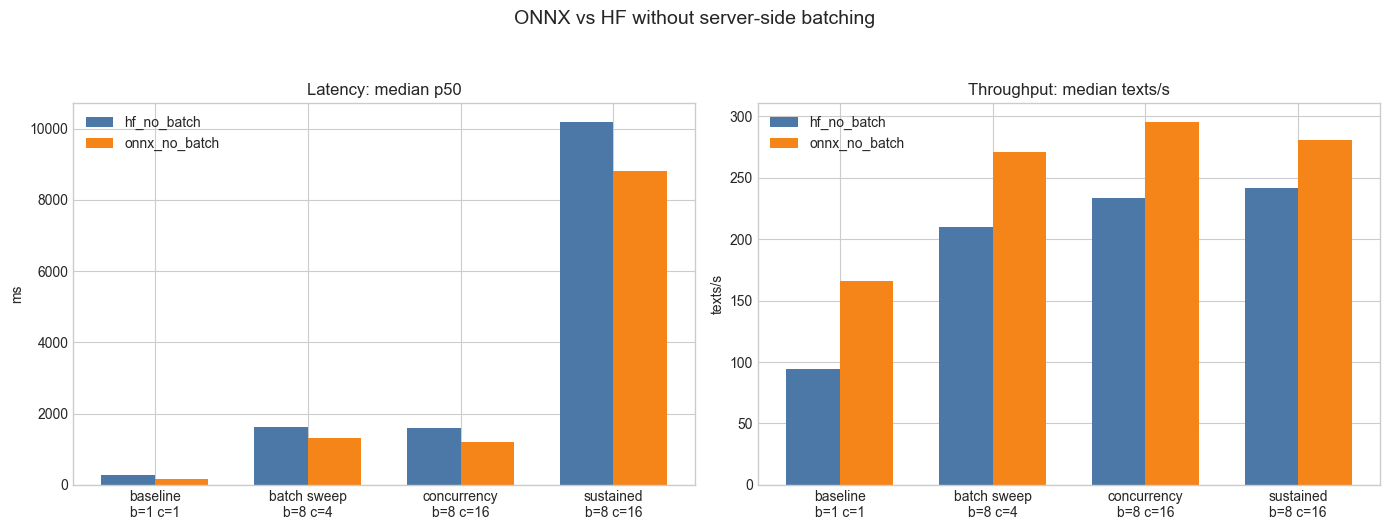

Подтверждение вывода: во всех ключевых сценариях у onnx_no_batch p50 ниже, а texts/s выше.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [scenario_label(key) for key in KEY_SCENARIOS]
x = range(len(KEY_SCENARIOS))
width = 0.35

hf_p50 = [summary["hf_no_batch"][key]["p50"] for key in KEY_SCENARIOS]
onnx_p50 = [summary["onnx_no_batch"][key]["p50"] for key in KEY_SCENARIOS]
hf_tps = [summary["hf_no_batch"][key]["texts_s"] for key in KEY_SCENARIOS]
onnx_tps = [summary["onnx_no_batch"][key]["texts_s"] for key in KEY_SCENARIOS]

axes[0].bar([i - width / 2 for i in x], hf_p50, width=width, label="hf_no_batch", color="#4C78A8")
axes[0].bar([i + width / 2 for i in x], onnx_p50, width=width, label="onnx_no_batch", color="#F58518")
axes[0].set_title("Latency: median p50")
axes[0].set_ylabel("ms")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].legend()

axes[1].bar([i - width / 2 for i in x], hf_tps, width=width, label="hf_no_batch", color="#4C78A8")
axes[1].bar([i + width / 2 for i in x], onnx_tps, width=width, label="onnx_no_batch", color="#F58518")
axes[1].set_title("Throughput: median texts/s")
axes[1].set_ylabel("texts/s")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].legend()

fig.suptitle("ONNX vs HF without server-side batching", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Подтверждение вывода: во всех ключевых сценариях у onnx_no_batch p50 ниже, а texts/s выше.")

## 2. Почему `BATCH_WINDOW_MS=500` выглядит неудачным

Следующий график показывает относительное изменение при включении batching относительно режима `no_batch` для того же backend.

Здесь удобно смотреть сразу два сигнала:

- `texts/s delta`: если столбец уходит вниз, batching снижает throughput;
- `p50 delta`: если столбец уходит вверх, batching увеличивает latency.

Если почти везде получается именно такая комбинация, значит batching с окном `500 ms` добавляет ожидание быстрее, чем приносит пользу от объединения запросов.

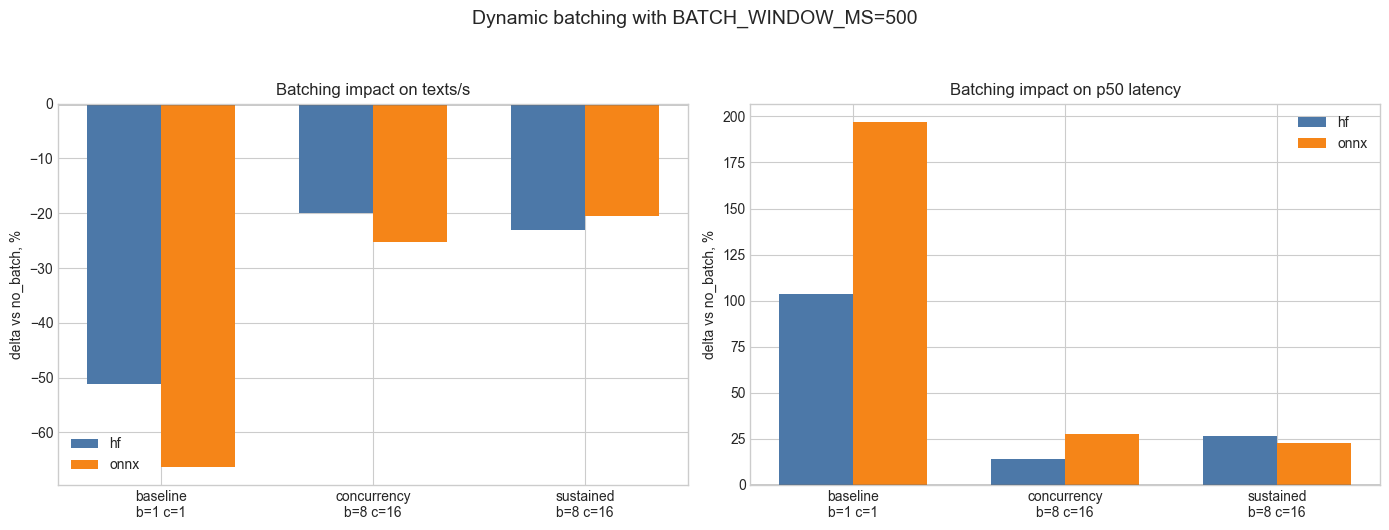

Подтверждение вывода: почти все столбцы texts/s ниже нуля, а p50 выше нуля.


In [6]:
focus = [
    ("baseline", 1, 1),
    ("conc_sweep", 8, 16),
    ("sustained", 8, 16),
]
labels = [scenario_label(key) for key in focus]
x = range(len(focus))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for offset, backend, color in [(-width / 2, "hf", "#4C78A8"), (width / 2, "onnx", "#F58518")]:
    texts_delta = []
    p50_delta = []
    for key in focus:
        no_batch = summary[f"{backend}_no_batch"][key]
        with_batch = summary[f"{backend}_batch_bw500"][key]
        texts_delta.append(pct_change(with_batch["texts_s"], no_batch["texts_s"]))
        p50_delta.append(pct_change(with_batch["p50"], no_batch["p50"]))

    axes[0].bar([i + offset for i in x], texts_delta, width=width, label=backend, color=color)
    axes[1].bar([i + offset for i in x], p50_delta, width=width, label=backend, color=color)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Batching impact on texts/s")
axes[0].set_ylabel("delta vs no_batch, %")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Batching impact on p50 latency")
axes[1].set_ylabel("delta vs no_batch, %")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].legend()

fig.suptitle("Dynamic batching with BATCH_WINDOW_MS=500", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Подтверждение вывода: почти все столбцы texts/s ниже нуля, а p50 выше нуля.")

## 3. Trade-off: batching экономит RAM, но не ускоряет сервис

В отчете это был главный контраргумент против слишком жесткой формулировки "batching плохой". По скорости он почти везде проиграл, но по памяти в ряде сценариев явно выиграл.

Следующий график показывает именно компромисс: чем левее и выше точка, тем режим практичнее с точки зрения "меньше RAM, больше texts/s".

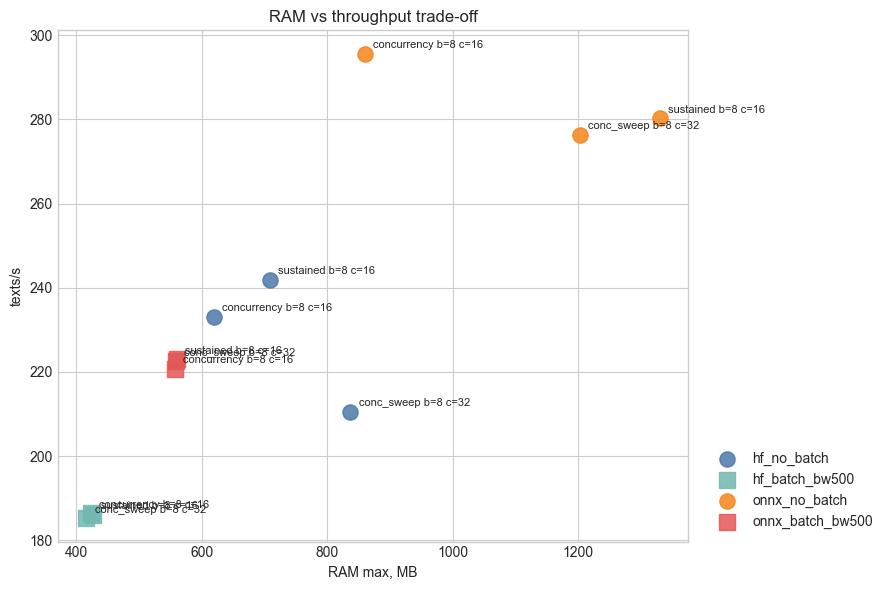

Подтверждение вывода: batching действительно двигает точки влево по RAM, особенно для onnx, но обычно и вниз по texts/s.


In [7]:
tradeoff_points = [
    ("conc_sweep", 8, 16),
    ("conc_sweep", 8, 32),
    ("sustained", 8, 16),
]
mode_style = {
    "hf_no_batch": ("#4C78A8", "o"),
    "hf_batch_bw500": ("#72B7B2", "s"),
    "onnx_no_batch": ("#F58518", "o"),
    "onnx_batch_bw500": ("#E45756", "s"),
}

fig, ax = plt.subplots(figsize=(9, 6))
for mode, (color, marker) in mode_style.items():
    xs = [summary[mode][key]["ram_max"] for key in tradeoff_points]
    ys = [summary[mode][key]["texts_s"] for key in tradeoff_points]
    ax.scatter(xs, ys, s=120, color=color, marker=marker, alpha=0.85, label=mode)
    for key, x, y in zip(tradeoff_points, xs, ys):
        ax.annotate(scenario_label(key).replace("\n", " "), (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_title("RAM vs throughput trade-off")
ax.set_xlabel("RAM max, MB")
ax.set_ylabel("texts/s")
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.0))
plt.tight_layout()
plt.show()

print("Подтверждение вывода: batching действительно двигает точки влево по RAM, особенно для onnx, но обычно и вниз по texts/s.")

## 4. Почему `no_batch` не равно "по одному тексту"

Это важная часть интерпретации. В `run_benchmark.py` сценарий `batch_sweep` уже сам меняет размер `payload`: `1`, `8`, `16`, `32`. Поэтому `*_no_batch.csv` не означают, что сервис всегда обрабатывал только один текст.

Последний график показывает эффект batching на уровне запроса при отключенном server-side batching. Он нужен, чтобы не перепутать два разных механизма:

- batching внутри одного HTTP-запроса;
- server-side dynamic batching между разными запросами.

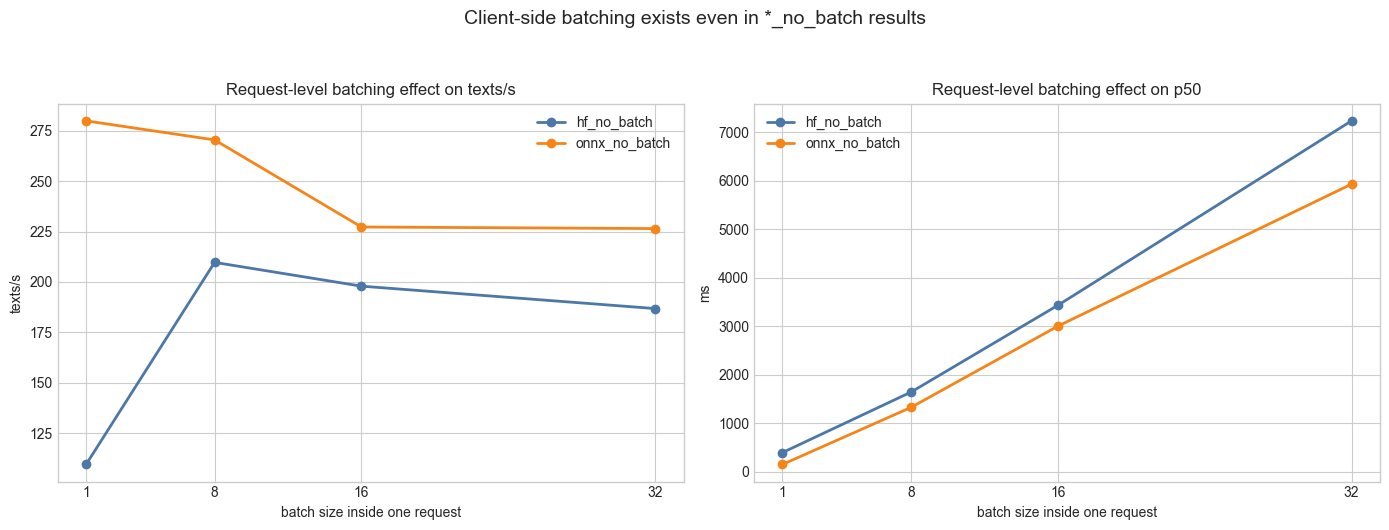

Подтверждение вывода: no_batch здесь означает только отсутствие server-side dynamic batching, а не отсутствие batch в payload.


In [8]:
batch_keys = [
    ("batch_sweep", 1, 4),
    ("batch_sweep", 8, 4),
    ("batch_sweep", 16, 4),
    ("batch_sweep", 32, 4),
]

batch_sizes = [key[1] for key in batch_keys]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mode, color in [("hf_no_batch", "#4C78A8"), ("onnx_no_batch", "#F58518")]:
    texts_s = [summary[mode][key]["texts_s"] for key in batch_keys]
    p50 = [summary[mode][key]["p50"] for key in batch_keys]
    axes[0].plot(batch_sizes, texts_s, marker="o", linewidth=2, label=mode, color=color)
    axes[1].plot(batch_sizes, p50, marker="o", linewidth=2, label=mode, color=color)

axes[0].set_title("Request-level batching effect on texts/s")
axes[0].set_xlabel("batch size inside one request")
axes[0].set_ylabel("texts/s")
axes[0].set_xticks(batch_sizes)
axes[0].legend()

axes[1].set_title("Request-level batching effect on p50")
axes[1].set_xlabel("batch size inside one request")
axes[1].set_ylabel("ms")
axes[1].set_xticks(batch_sizes)
axes[1].legend()

fig.suptitle("Client-side batching exists even in *_no_batch results", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Подтверждение вывода: no_batch здесь означает только отсутствие server-side dynamic batching, а не отсутствие batch в payload.")

## Финальный вывод

Инфографика подтверждает отчет:

- если нужна максимальная производительность, лучший режим в этих замерах это `onnx_no_batch`;
- `BATCH_WINDOW_MS=500` оказался слишком большим для этой нагрузки: batching почти везде ухудшил latency и throughput;
- при этом batching полезен как режим экономии памяти, особенно для `onnx`;
- отдельный следующий шаг для исследования: повторить те же замеры с меньшим окном, например `10-50 ms`, и посмотреть, останется ли тот же баланс между latency, throughput и RAM.